In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [7]:
df = pd.read_csv('netflix_titles.csv')

In [8]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [10]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [11]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["date_added"] = df["date_added"].fillna(df["date_added"].mode()[0])
df["country"] = df["country"].fillna(df["country"].mode()[0])
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])
df["duration"] = df["duration"].fillna(df["duration"].mode()[0])

In [14]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [15]:
df["date_added"] = pd.to_datetime(
    df["date_added"].astype(str).str.strip(),
    format="mixed",
    errors="coerce"
)

In [16]:
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()

In [17]:
df.dtypes

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
year_added               int32
month_added             object
dtype: object

In [18]:
df.to_csv("netflix_cleaned.csv", index=False)

In [19]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
count,8807,8807,8807,8807,8807,8807,8807,8807.000000,8807,8807,8807,8807,8807.000000,8807
unique,8807,2,8807,4529,7693,748,NaN,NaN,17,220,514,8775,NaN,12
top,s8807,Movie,Zubaan,Unknown,Unknown,United States,NaN,NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope...",NaN,July
freq,1,6131,1,2634,825,3649,NaN,NaN,3211,1796,362,4,NaN,827
mean,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-17 12:13:09.735437824,2014.180198,NaN,NaN,NaN,NaN,2018.873169,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-01 00:00:00,1925.000000,NaN,NaN,NaN,NaN,2008.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-06 00:00:00,2013.000000,NaN,NaN,NaN,NaN,2018.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-04 00:00:00,2017.000000,NaN,NaN,NaN,NaN,2019.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-18 00:00:00,2019.000000,NaN,NaN,NaN,NaN,2020.000000,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-25 00:00:00,2021.000000,NaN,NaN,NaN,NaN,2021.000000,NaN


In [20]:
df = pd.read_csv("netflix_cleaned.csv")

df["date_added"] = pd.to_datetime(df["date_added"])

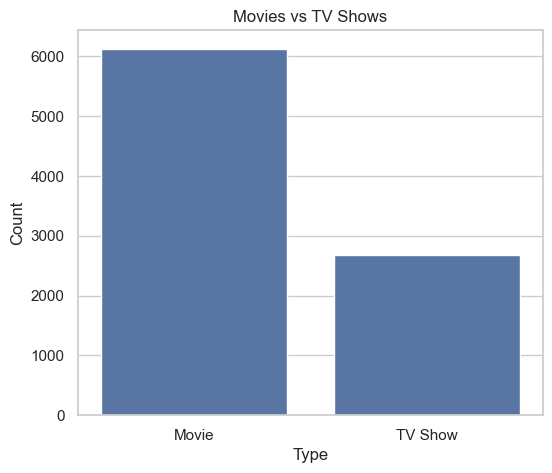

In [21]:
plt.figure(figsize=(6,5))

sns.countplot(x="type", data=df)

plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

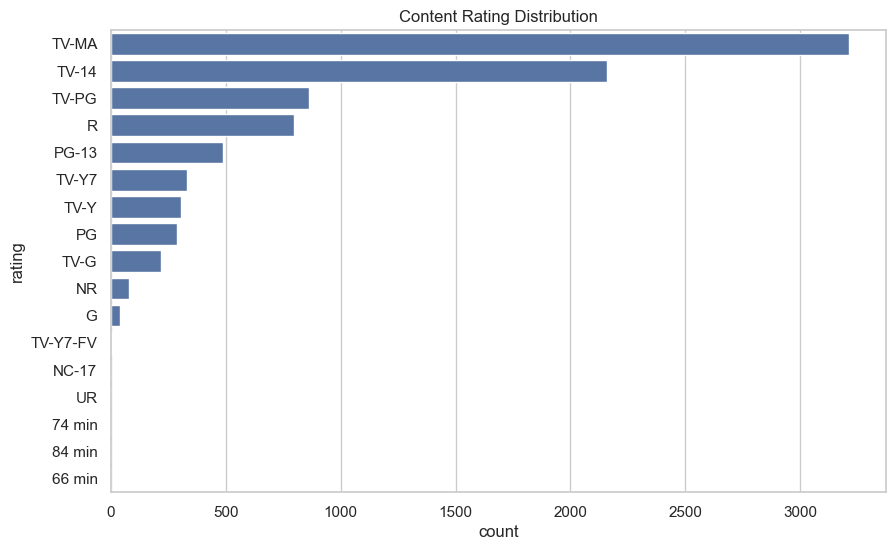

In [22]:
plt.figure(figsize=(10,6))

sns.countplot(
    y="rating",
    data=df,
    order=df["rating"].value_counts().index
)

plt.title("Content Rating Distribution")

plt.show()

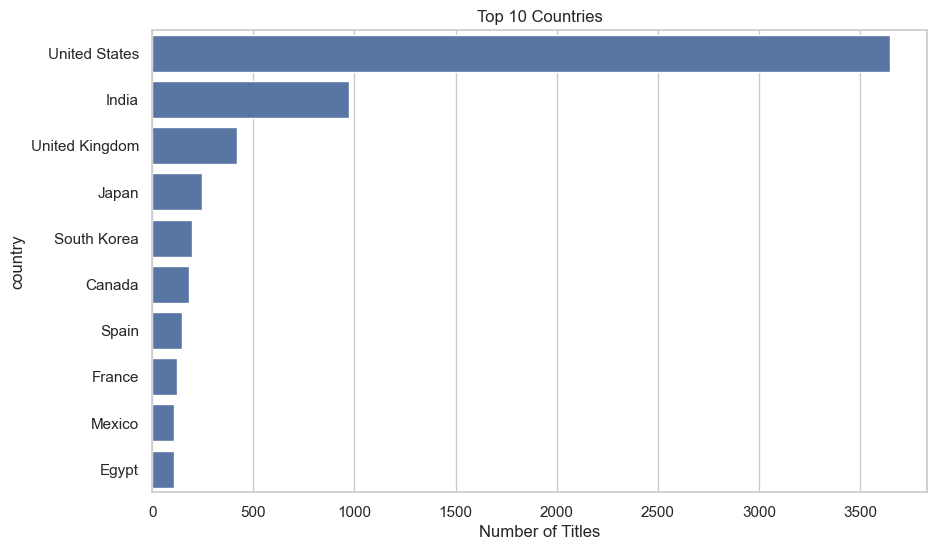

In [23]:
top_country = df["country"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_country.values,
    y=top_country.index
)

plt.title("Top 10 Countries")
plt.xlabel("Number of Titles")

plt.show()

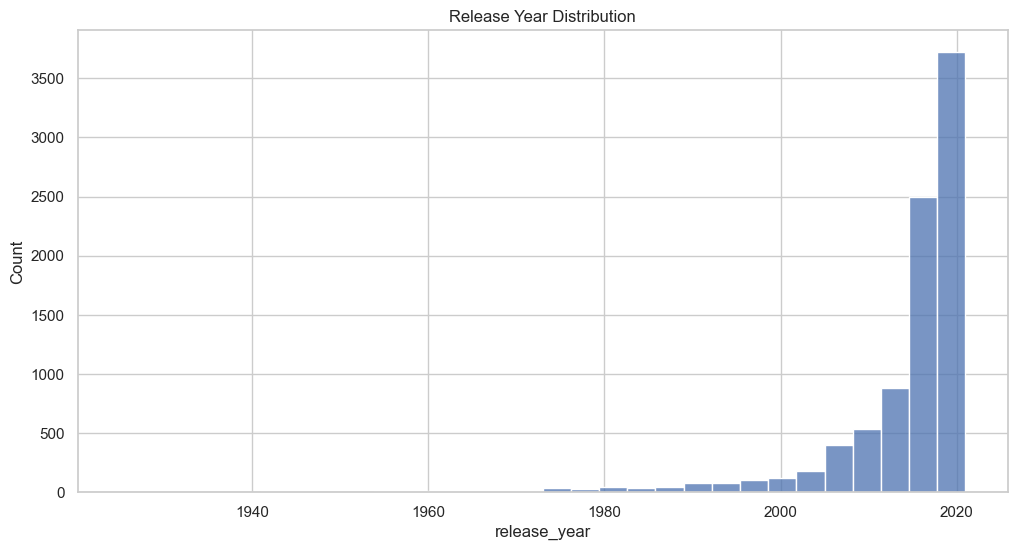

In [24]:
plt.figure(figsize=(12,6))

sns.histplot(df["release_year"], bins=30)

plt.title("Release Year Distribution")

plt.show()

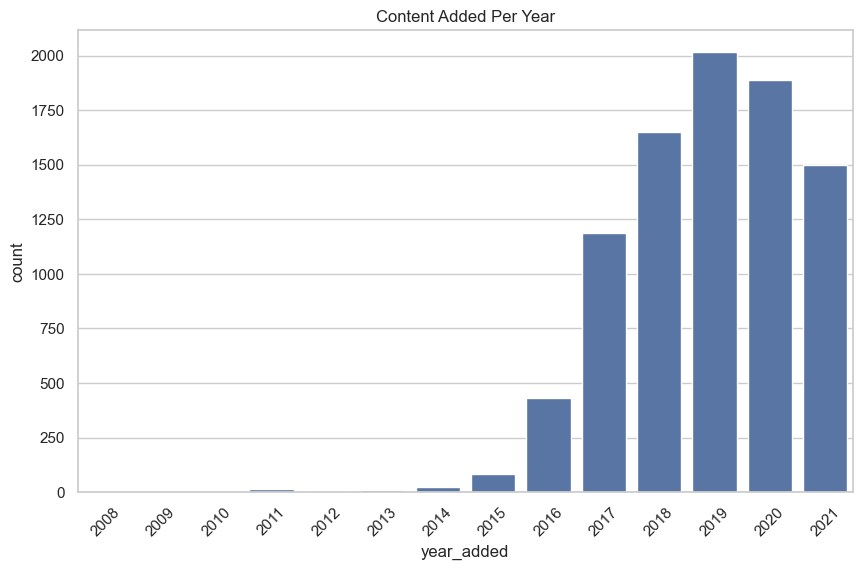

In [25]:
plt.figure(figsize=(10,6))

sns.countplot(
    x="year_added",
    data=df,
    order=sorted(df["year_added"].unique())
)

plt.xticks(rotation=45)

plt.title("Content Added Per Year")

plt.show()

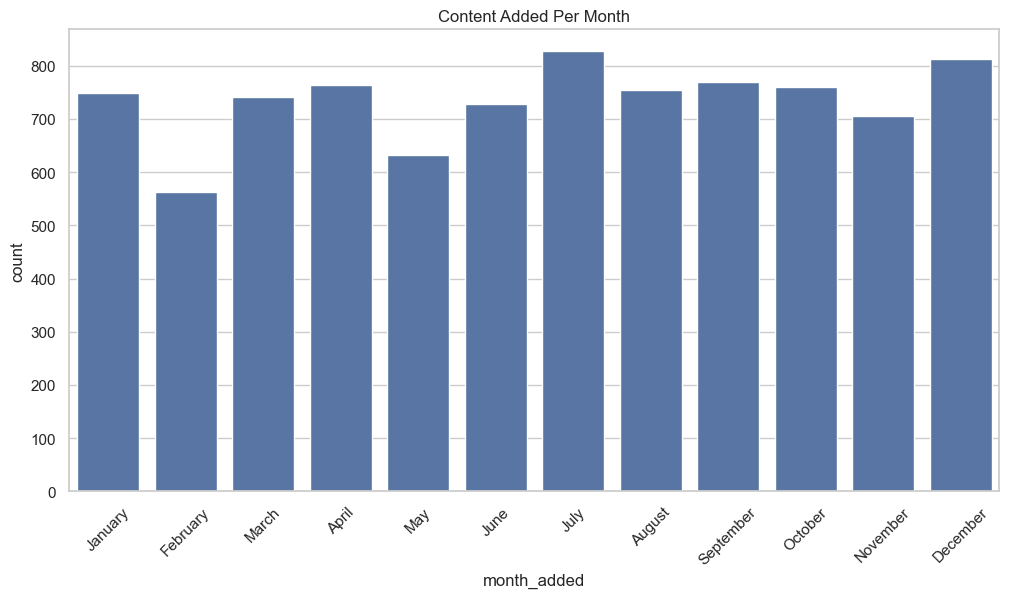

In [26]:
months = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

plt.figure(figsize=(12,6))

sns.countplot(
    x="month_added",
    data=df,
    order=months
)

plt.xticks(rotation=45)

plt.title("Content Added Per Month")

plt.show()

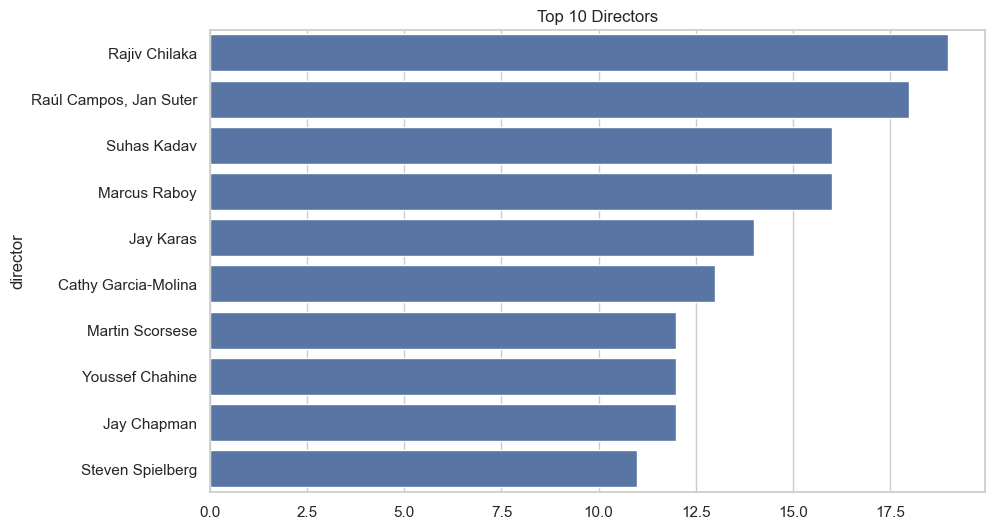

In [27]:
top_directors = (
    df[df["director"] != "Unknown"]["director"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title("Top 10 Directors")

plt.show()

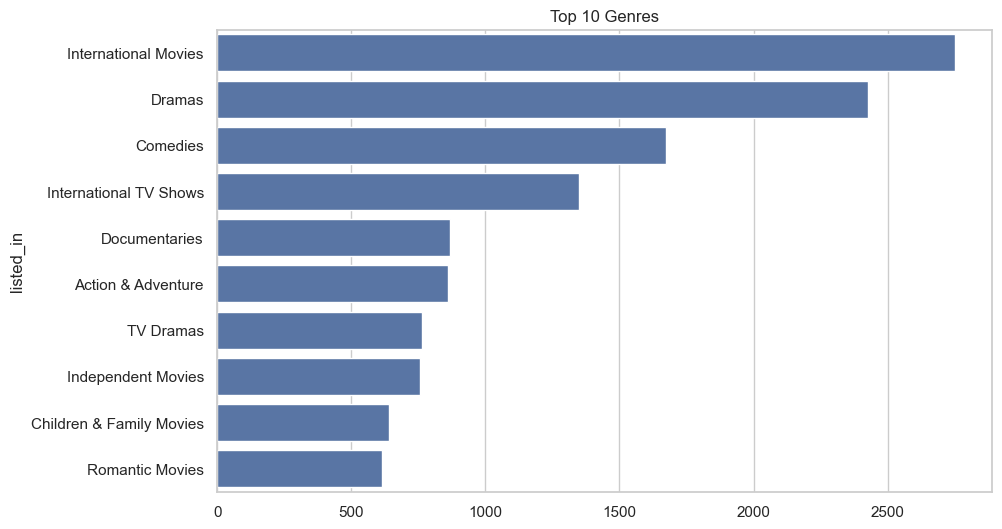

In [28]:
top_genres = (
    df["listed_in"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Genres")

plt.show()

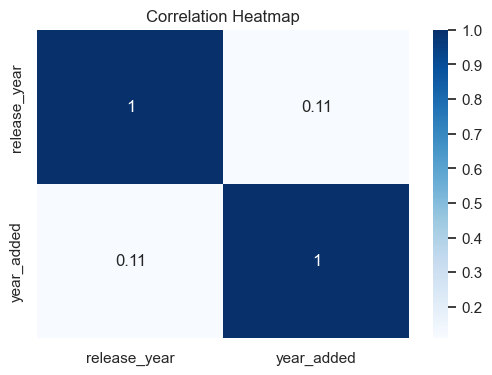

In [29]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

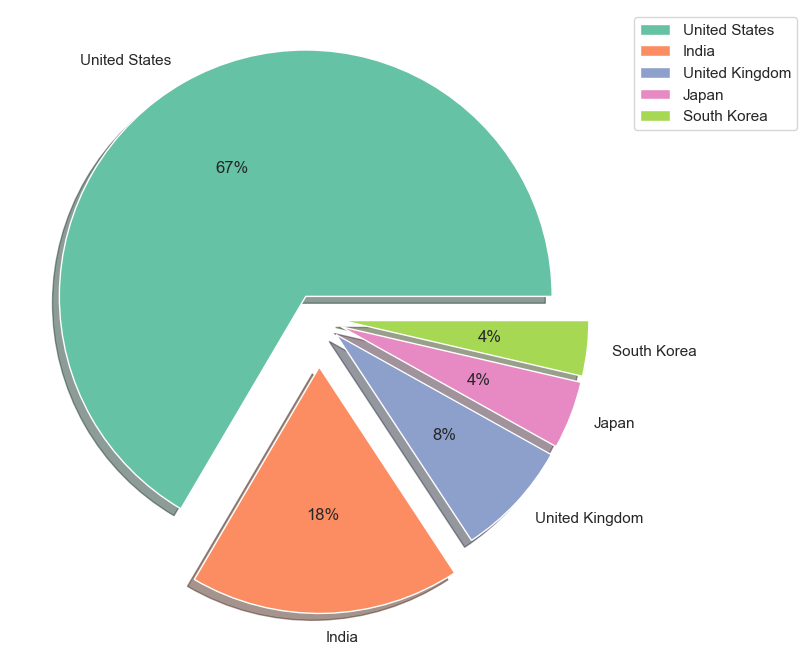

In [30]:
plt.figure(figsize=(8, 8))
top_5_countries = top_country.head(5)

values = top_5_countries.values
cars = top_5_countries.index.tolist()
colors = sns.color_palette("Set2", n_colors=len(values))

plt.pie(
    values,
    labels=cars,
    colors=colors,
    autopct="%1.0f%%",
    explode=[0.1, 0.2, 0.1, 0.1, 0.1],
    shadow=True
)

plt.legend(cars, bbox_to_anchor=(1.0, 1.0))
plt.show()
